In [2]:
# LIBRERÍAS
# Solo se usan librerías de cálculo y visualización — sin frameworks de modelamiento
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# CARGA DE DATOS
df = pd.read_csv('data.csv', sep=';')

# Limpiamos espacios en nombres de columnas (el dataset tiene algunos con tabulaciones)
df.columns = [col.strip() for col in df.columns]

print(f"Dimensiones del dataset: {df.shape}")
print("\nPrimeras filas:")
print(df.head())
print("\nTipos de datos:")
print(df.dtypes)

Dimensiones del dataset: (4424, 37)

Primeras filas:
   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1             

Distribución original de la variable Target:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Valores nulos en todo el dataset: 0


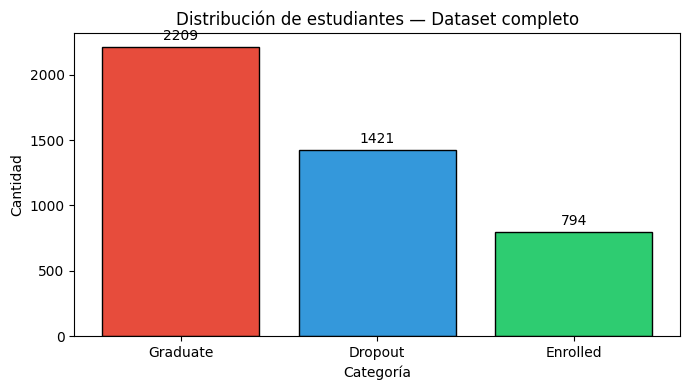

In [4]:
# EDA — DISTRIBUCIÓN DE CLASES ORIGINAL
print("Distribución original de la variable Target:")
print(df['Target'].value_counts())
print(f"\nValores nulos en todo el dataset: {df.isnull().sum().sum()}")

fig, ax = plt.subplots(figsize=(7, 4))
conteos = df['Target'].value_counts()
bars = ax.bar(conteos.index, conteos.values, color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='black')
ax.bar_label(bars, fmt='%d', padding=3)
ax.set_title("Distribución de estudiantes — Dataset completo")
ax.set_xlabel("Categoría")
ax.set_ylabel("Cantidad")
plt.tight_layout()
plt.show()

# El dataset tiene 3 clases: Dropout, Graduate y Enrolled.
# Los estudiantes 'Enrolled' aún no tienen un resultado final conocido,
# por lo que se excluyen para mantener un problema de clasificación binaria limpio.

In [5]:
# FILTRADO PARA CLASIFICACIÓN BINARIA
# Eliminamos los estudiantes 'Enrolled' ya que no tienen resultado definitivo
df = df[df['Target'] != 'Enrolled'].copy()

df['Target'] = df['Target'].map({
    'Dropout': 0,   # Clase 0: desertó
    'Graduate': 1   # Clase 1: se graduó
})

print("Nueva distribución (binaria):")
print(df['Target'].value_counts())
print(f"\nTotal de muestras: {len(df)}")
print(f"Proporción Dropout:  {df['Target'].value_counts()[0]/len(df)*100:.1f}%")
print(f"Proporción Graduate: {df['Target'].value_counts()[1]/len(df)*100:.1f}%")

# Existe un leve desbalance (39% Dropout vs 61% Graduate) que consideraremos
# al evaluar métricas — accuracy sola no es suficiente.

Nueva distribución (binaria):
Target
1    2209
0    1421
Name: count, dtype: int64

Total de muestras: 3630
Proporción Dropout:  39.1%
Proporción Graduate: 60.9%


C:\Users\vicrt\AppData\Local\Temp\ipykernel_9088\3031122012.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, ax=ax,
C:\Users\vicrt\AppData\Local\Temp\ipykernel_9088\3031122012.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, ax=ax,
C:\Users\vicrt\AppData\Local\Temp\ipykernel_9088\3031122012.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, ax=ax,
C:\Users\vicrt\AppData\Local\Temp\ipykernel_9088\3031122012.py:20: FutureWarning: 

Passing `palette` w

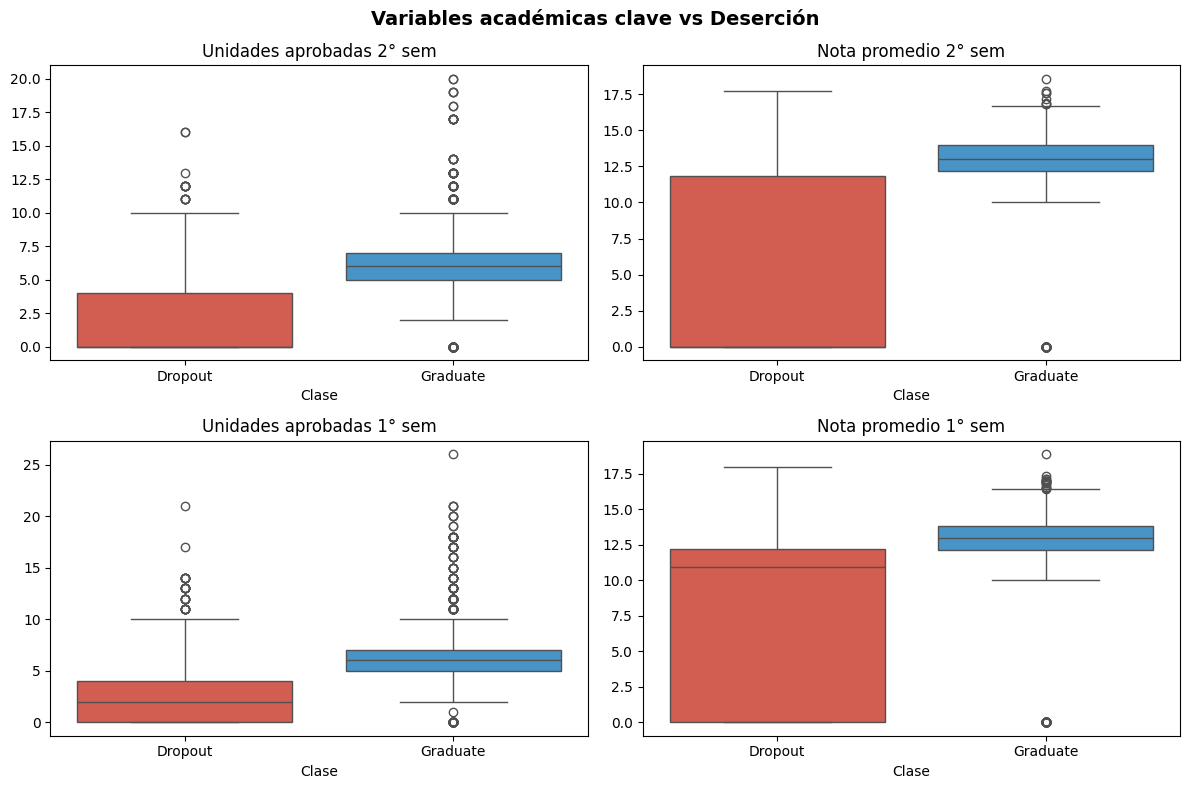

In [6]:
# EDA — ANÁLISIS EXPLORATORIO DE VARIABLES CLAVE

# Las 4 variables con mayor correlación con el target son las notas
# y unidades curriculares aprobadas en ambos semestres.
# Esto tiene sentido: un estudiante que aprueba pocas materias tiene mayor riesgo de desertar.

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Variables académicas clave vs Deserción", fontsize=14, fontweight='bold')

variables = [
    ('Curricular units 2nd sem (approved)', 'Unidades aprobadas 2° sem'),
    ('Curricular units 2nd sem (grade)',    'Nota promedio 2° sem'),
    ('Curricular units 1st sem (approved)', 'Unidades aprobadas 1° sem'),
    ('Curricular units 1st sem (grade)',    'Nota promedio 1° sem'),
]

labels = {0: 'Dropout', 1: 'Graduate'}

for ax, (col, titulo) in zip(axes.flatten(), variables):
    sns.boxplot(x='Target', y=col, data=df, ax=ax,
                palette=['#e74c3c', '#3498db'])
    ax.set_title(titulo)
    ax.set_xlabel("Clase")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Dropout', 'Graduate'])
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


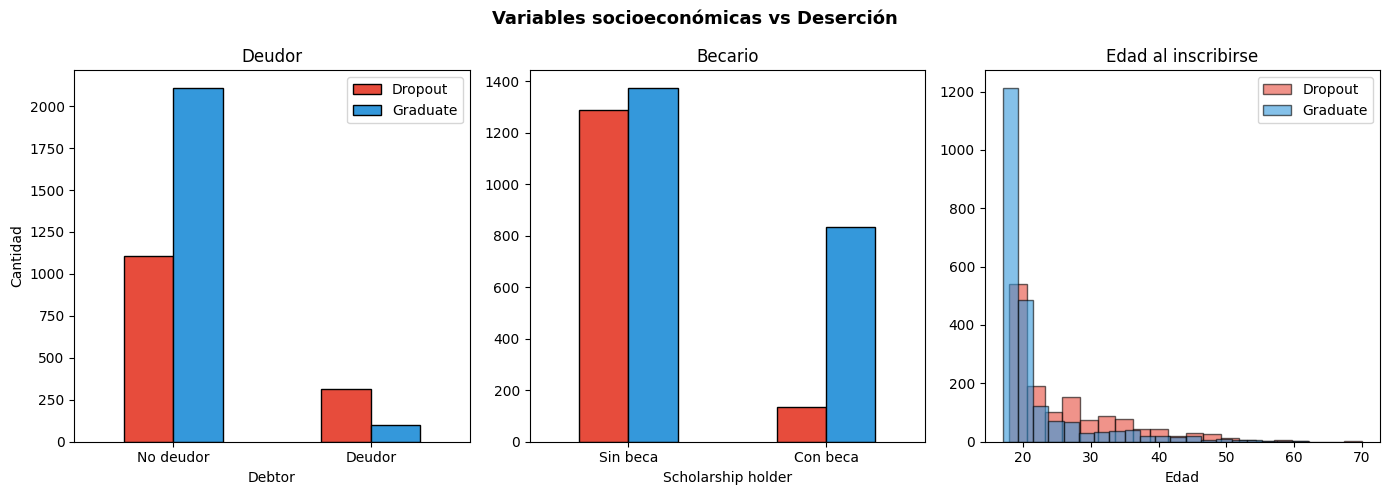

In [7]:
# EDA — VARIABLES SOCIOECONÓMICAS Y DEMOGRÁFICAS

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Variables socioeconómicas vs Deserción", fontsize=13, fontweight='bold')

# 1. Deudor
conteo_deudor = df.groupby(['Debtor', 'Target']).size().unstack(fill_value=0)
conteo_deudor.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#3498db'],
                   edgecolor='black', legend=True)
axes[0].set_title("Deudor")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No deudor', 'Deudor'], rotation=0)
axes[0].legend(['Dropout', 'Graduate'])
axes[0].set_ylabel("Cantidad")

# 2. Becario
conteo_beca = df.groupby(['Scholarship holder', 'Target']).size().unstack(fill_value=0)
conteo_beca.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#3498db'],
                 edgecolor='black', legend=False)
axes[1].set_title("Becario")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Sin beca', 'Con beca'], rotation=0)
axes[1].set_ylabel("")

# 3. Distribución de edad al momento de inscripción
for target_val, color, label in [(0, '#e74c3c', 'Dropout'), (1, '#3498db', 'Graduate')]:
    subset = df[df['Target'] == target_val]['Age at enrollment']
    axes[2].hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='black')
axes[2].set_title("Edad al inscribirse")
axes[2].set_xlabel("Edad")
axes[2].set_ylabel("")
axes[2].legend()

plt.tight_layout()
plt.show()

# Observaciones:
# - Los deudores tienen una tasa de deserción visiblemente mayor.
# - Los becarios tienen mejor tasa de graduación.
# - Los estudiantes que desertan tienden a ser algo mayores al inscribirse.


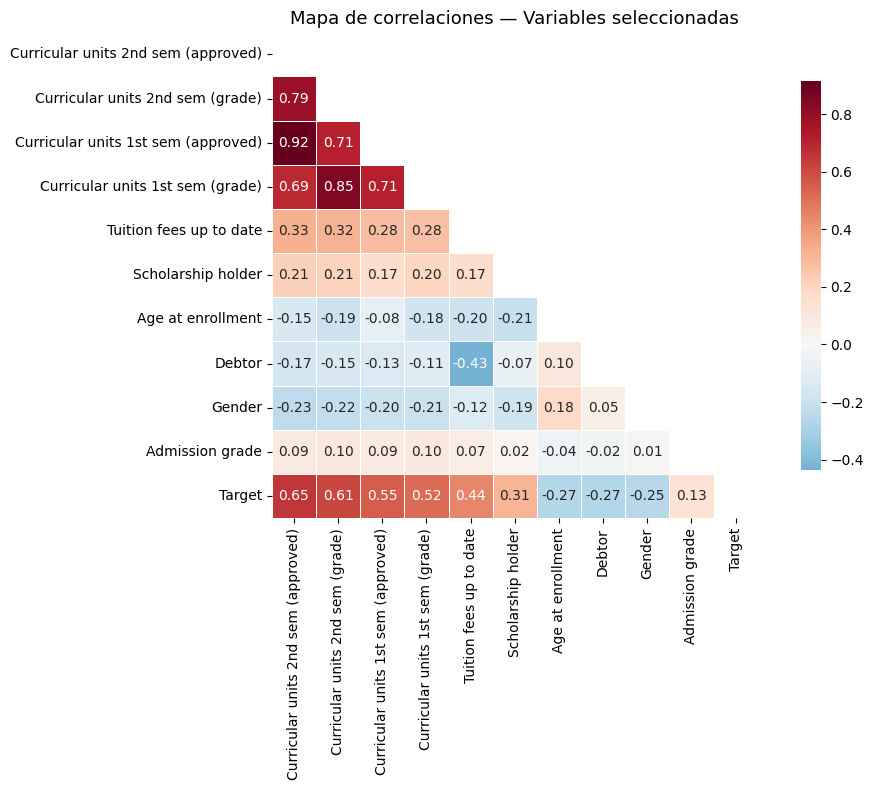

In [8]:
# EDA — MAPA DE CORRELACIONES (variables numéricas seleccionadas vs Target)

# Seleccionamos las variables numéricas continuas más relevantes para visualizar
vars_correlacion = [
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Tuition fees up to date',
    'Scholarship holder',
    'Age at enrollment',
    'Debtor',
    'Gender',
    'Admission grade',
    'Target'
]

corr_matrix = df[vars_correlacion].corr()

plt.figure(figsize=(11, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Mapa de correlaciones — Variables seleccionadas", fontsize=13)
plt.tight_layout()
plt.show()

# La última fila muestra la correlación de cada variable con el Target.
# Las unidades aprobadas y notas del 2° semestre son los predictores más fuertes.

In [ ]:
# PREPROCESAMIENTO — ONE-HOT ENCODING Y DIVISIÓN TRAIN/TEST

# Columnas categóricas que necesitan codificación
categorical_cols = [
    'Marital status',
    'Application mode',
    'Course',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation"
]

# Separamos X e y ANTES del encoding para evitar data leakage
X_raw = df.drop('Target', axis=1)
y = df['Target'].values.reshape(-1, 1)

# División manual de índices (80% train / 20% test)
np.random.seed(42)
indices = np.random.permutation(len(X_raw))
limite = int(0.8 * len(X_raw))
idx_train = indices[:limite]
idx_test  = indices[limite:]

X_train_raw = X_raw.iloc[idx_train].copy()
X_test_raw  = X_raw.iloc[idx_test].copy()
y_train = y[idx_train]
y_test  = y[idx_test]

# Aplicamos get_dummies ajustado al train, alineamos columnas en test
X_train_enc = pd.get_dummies(X_train_raw, columns=categorical_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test_raw,  columns=categorical_cols, drop_first=True)

# Alineamos columnas: el test puede tener menos categorías que el train
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print(f"Features tras encoding: {X_train_enc.shape[1]}")
print(f"Entrenamiento: {X_train_enc.shape[0]} muestras")
print(f"Prueba:        {X_test_enc.shape[0]} muestras")

Features tras encoding: 200
Entrenamiento: 2904 muestras
Prueba:        726 muestras


In [ ]:
# ESCALADO MANUAL (Z-score) — Sin data leakage
# Los parámetros de escalado (media y std) se calculan SOLO con train
# y luego se aplican al test. Esto es fundamental para no filtrar
# información del conjunto de prueba al entrenamiento.

X_train_vals = X_train_enc.values.astype(float)
X_test_vals  = X_test_enc.values.astype(float)

# Calculamos media y desviación estándar solo del conjunto de entrenamiento
mean_train = np.mean(X_train_vals, axis=0)
std_train  = np.std(X_train_vals, axis=0)
std_train[std_train == 0] = 1  # Evitamos división por cero en columnas constantes

# Aplicamos la misma transformación a ambos conjuntos
X_train_scaled = (X_train_vals - mean_train) / std_train
X_test_scaled  = (X_test_vals  - mean_train) / std_train

# Añadimos columna de bias (columna de unos) al inicio
X_train_final = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_test_final  = np.hstack([np.ones((X_test_scaled.shape[0],  1)), X_test_scaled])

print(f"Shape train final: {X_train_final.shape}")
print(f"Shape test final:  {X_test_final.shape}")

Shape train final: (2904, 201)
Shape test final:  (726, 201)


In [ ]:
# FUNCIONES DEL MODELO — REGRESIÓN LOGÍSTICA

def sigmoid(z):
    """
    Función de activación sigmoide: mapea cualquier valor real al intervalo (0, 1).
    Se usa para interpretar la salida como una probabilidad.
    σ(z) = 1 / (1 + e^(-z))
    """
    return 1 / (1 + np.exp(-z))


def calcular_costo(X, y, theta):
    """
    Función de costo: Binary Cross-Entropy (Log-Loss).
    Mide qué tan lejos están las predicciones de los valores reales.
    J(θ) = (-1/m) * Σ [ y·log(h) + (1-y)·log(1-h) ]
    El término 1e-15 evita log(0) que produce -inf.
    """
    m = len(y)
    h = sigmoid(np.dot(X, theta))
    costo = (-1/m) * (
        np.dot(y.T, np.log(h + 1e-15)) +
        np.dot((1 - y).T, np.log(1 - h + 1e-15))
    )
    return costo[0][0]


def gradient_descent(X, y, theta, alpha, iterations, tolerancia=1e-6):
    """
    Algoritmo de Gradiente Descendente para optimizar los parámetros θ.

    Parámetros:
    -----------
    X          : matriz de features con bias (m x n)
    y          : vector de etiquetas (m x 1)
    theta      : parámetros iniciales (n x 1)
    alpha      : tasa de aprendizaje (learning rate)
    iterations : número máximo de iteraciones
    tolerancia : criterio de parada por convergencia (cambio mínimo en costo)

    Retorna:
    --------
    theta        : parámetros optimizados
    cost_history : historial del costo por iteración

    Actualización:
    θ := θ - α · (1/m) · Xᵀ · (h - y)
    donde h = σ(Xθ) es la predicción actual.
    """
    m = len(y)
    cost_history = []

    for i in range(iterations):
        # Predicción actual
        h = sigmoid(np.dot(X, theta))

        # Gradiente de la función de costo respecto a θ
        gradient = (1/m) * np.dot(X.T, (h - y))

        # Actualización de parámetros
        theta = theta - alpha * gradient

        # Calculamos y registramos el costo actual
        costo_actual = calcular_costo(X, y, theta)
        cost_history.append(costo_actual)

        # Criterio de convergencia: si el costo apenas cambia, paramos
        if i > 0 and abs(cost_history[-2] - cost_history[-1]) < tolerancia:
            print(f"Convergencia alcanzada en iteración {i} (Δcosto < {tolerancia})")
            break

        if i % 200 == 0:
            print(f"  Iteración {i:4d} | Costo: {costo_actual:.6f}")

    return theta, cost_history

  Iteración    0 | Costo: 0.692550
  Iteración  200 | Costo: 0.598206
  Iteración  400 | Costo: 0.537721
  Iteración    0 | Costo: 0.687210
  Iteración  200 | Costo: 0.371140
  Iteración  400 | Costo: 0.312070
  Iteración    0 | Costo: 0.664215
  Iteración  200 | Costo: 0.255600
  Iteración  400 | Costo: 0.229934
  Iteración    0 | Costo: 0.637159
  Iteración  200 | Costo: 0.229800
  Iteración  400 | Costo: 0.213780


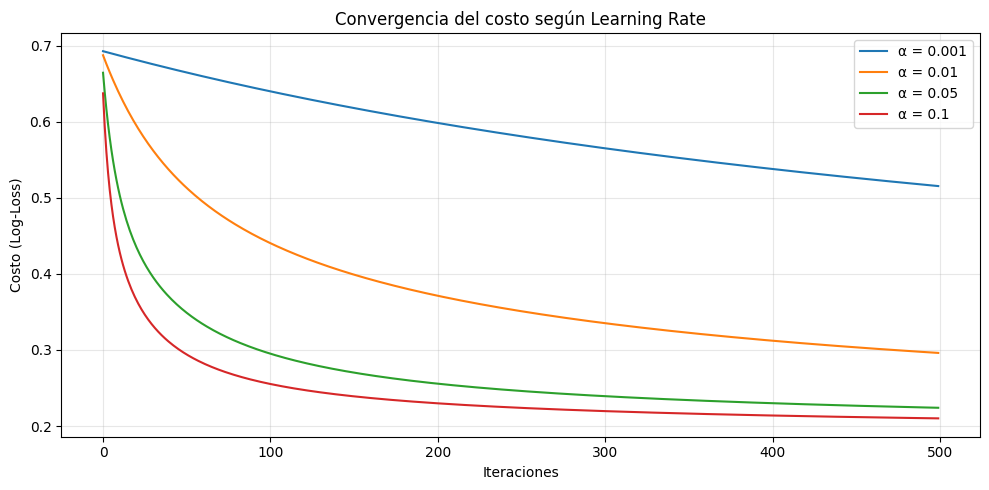

In [12]:
# SELECCIÓN DE LEARNING RATE — Experimento numérico
# Evaluamos distintos valores de alpha para elegir el óptimo.
# Un alpha muy grande puede causar divergencia; uno muy pequeño, convergencia lenta.

alphas_a_probar = [0.001, 0.01, 0.05, 0.1]
n_features = X_train_final.shape[1]
iteraciones_exp = 500

plt.figure(figsize=(10, 5))

for alpha_exp in alphas_a_probar:
    theta_exp = np.zeros((n_features, 1))
    _, hist = gradient_descent(
        X_train_final, y_train, theta_exp,
        alpha=alpha_exp, iterations=iteraciones_exp, tolerancia=1e-8
    )
    plt.plot(hist, label=f'α = {alpha_exp}')

plt.title("Convergencia del costo según Learning Rate")
plt.xlabel("Iteraciones")
plt.ylabel("Costo (Log-Loss)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Resultado esperado:
# α=0.001 converge pero muy lento
# α=0.01  converge de forma estable — buen balance
# α=0.05 / 0.1 convergen más rápido pero pueden ser inestables
# Elegimos α=0.01 por ser estable y converger en ~1000 iteraciones

In [ ]:
# ENTRENAMIENTO FINAL

# Hiperparámetros seleccionados tras el experimento anterior
alpha      = 0.01   # Tasa de aprendizaje: balance entre velocidad y estabilidad
iterations = 1000   # Iteraciones máximas (el criterio de convergencia puede parar antes)

n_features = X_train_final.shape[1]
theta_inicial = np.zeros((n_features, 1))  # Inicialización en cero

print("Iniciando entrenamiento...")
print("-" * 45)

theta_final, cost_history = gradient_descent(
    X_train_final, y_train, theta_inicial,
    alpha=alpha, iterations=iterations, tolerancia=1e-6
)

print("-" * 45)
print(f"Costo inicial : {cost_history[0]:.6f}")
print(f"Costo final   : {cost_history[-1]:.6f}")
print(f"Reducción     : {(1 - cost_history[-1]/cost_history[0])*100:.1f}%")

Iniciando entrenamiento...
---------------------------------------------
  Iteración    0 | Costo: 0.687210
  Iteración  200 | Costo: 0.371140
  Iteración  400 | Costo: 0.312070
  Iteración  600 | Costo: 0.283872
  Iteración  800 | Costo: 0.267101
---------------------------------------------
Costo inicial : 0.687210
Costo final   : 0.255972
Reducción     : 62.8%


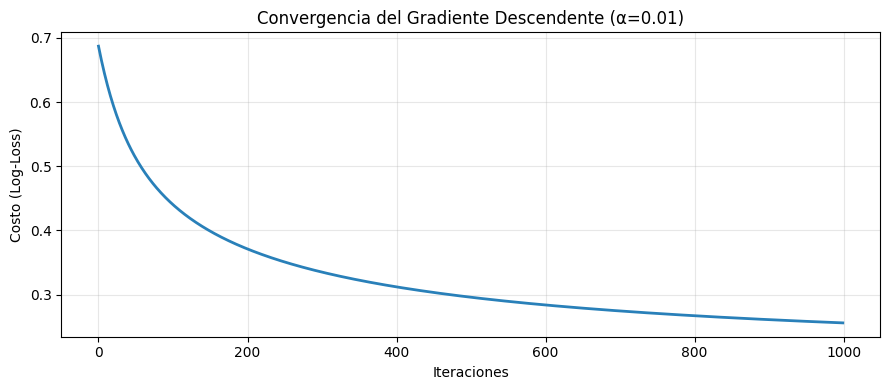

In [14]:
# EVOLUCIÓN DEL COSTO DURANTE EL ENTRENAMIENTO

plt.figure(figsize=(9, 4))
plt.plot(cost_history, color='#2980b9', linewidth=2)
plt.title("Convergencia del Gradiente Descendente (α=0.01)")
plt.xlabel("Iteraciones")
plt.ylabel("Costo (Log-Loss)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# La curva debe descender de forma suave y estabilizarse, lo que confirma que
# el modelo aprendió correctamente sin divergencias ni oscilaciones.

In [15]:
# PREDICCIONES EN EL CONJUNTO DE PRUEBA

# Calculamos la probabilidad de que cada estudiante se gradúe (clase 1)
prob_test = sigmoid(np.dot(X_test_final, theta_final))

# Umbral de decisión: si P(Graduate) >= 0.5 → predicción = 1 (Graduate)
pred_test = (prob_test >= 0.5).astype(int)

print(f"Total muestras en test: {len(y_test)}")
print(f"Predicciones Graduate: {pred_test.sum()}")
print(f"Predicciones Dropout:  {len(pred_test) - pred_test.sum()}")

Total muestras en test: 726
Predicciones Graduate: 476
Predicciones Dropout:  250


In [16]:
# EVALUACIÓN — MÉTRICAS COMPLETAS (calculadas manualmente)

def calcular_matriz(real, pred):
    """
    Calcula la matriz de confusión manualmente.
    Formato:
        [[TN, FP],
         [FN, TP]]
    TN: verdaderos negativos (Dropout correctamente identificado)
    FP: falsos positivos (Dropout clasificado como Graduate)
    FN: falsos negativos (Graduate clasificado como Dropout)
    TP: verdaderos positivos (Graduate correctamente identificado)
    """
    tp = np.sum((real == 1) & (pred == 1))
    tn = np.sum((real == 0) & (pred == 0))
    fp = np.sum((real == 0) & (pred == 1))
    fn = np.sum((real == 1) & (pred == 0))
    return np.array([[tn, fp], [fn, tp]]), tp, tn, fp, fn

# Aplanamos vectores para la comparación elemento a elemento
real_flat = y_test.flatten()
pred_flat = pred_test.flatten()

matriz, tp, tn, fp, fn = calcular_matriz(real_flat, pred_flat)

# Cálculo de métricas
accuracy  = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0

print("=" * 40)
print("       MÉTRICAS DE EVALUACIÓN")
print("=" * 40)
print(f"  Accuracy      : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision     : {precision:.4f}")
print(f"  Recall        : {recall:.4f}")
print(f"  F1-Score      : {f1:.4f}")
print(f"  Especificidad : {especificidad:.4f}")
print("=" * 40)
print("\nMatriz de Confusión:")
print(f"  [[TN={tn}  FP={fp}]")
print(f"   [FN={fn}  TP={tp}]]")
print("\nInterpretación:")
print(f"  - De {tn+fp} estudiantes que desertaron, el modelo identificó correctamente {tn} ({tn/(tn+fp)*100:.1f}%)")
print(f"  - De {tp+fn} estudiantes que se graduaron, el modelo identificó correctamente {tp} ({tp/(tp+fn)*100:.1f}%)")

       MÉTRICAS DE EVALUACIÓN
  Accuracy      : 0.9022  (90.22%)
  Precision     : 0.8866
  Recall        : 0.9613
  F1-Score      : 0.9224
  Especificidad : 0.8118

Matriz de Confusión:
  [[TN=233  FP=54]
   [FN=17  TP=422]]

Interpretación:
  - De 287 estudiantes que desertaron, el modelo identificó correctamente 233 (81.2%)
  - De 439 estudiantes que se graduaron, el modelo identificó correctamente 422 (96.1%)


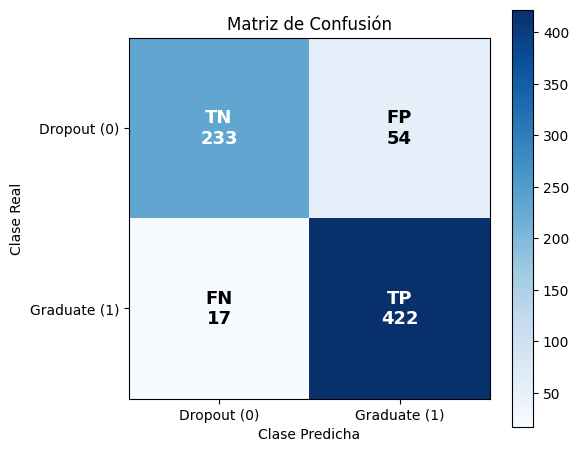

In [17]:
# VISUALIZACIÓN — MATRIZ DE CONFUSIÓN

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(matriz, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

clases = ['Dropout (0)', 'Graduate (1)']
tick_marks = np.arange(len(clases))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(clases)
ax.set_yticklabels(clases)

# Etiquetas en cada celda
umbral_color = matriz.max() / 2
for i in range(2):
    for j in range(2):
        etiqueta = ['TN', 'FP', 'FN', 'TP'][i*2 + j]
        ax.text(j, i, f'{etiqueta}\n{matriz[i, j]}',
                ha='center', va='center', fontsize=13, fontweight='bold',
                color='white' if matriz[i, j] > umbral_color else 'black')

ax.set_ylabel('Clase Real')
ax.set_xlabel('Clase Predicha')
ax.set_title('Matriz de Confusión')
plt.tight_layout()
plt.show()

In [20]:
# PRUEBA INDIVIDUAL — Predicción para un estudiante del conjunto de prueba

# Tomamos el primer estudiante del conjunto de prueba como ejemplo
ejemplo = X_test_final[0].reshape(1, -1)
prob_graduarse = sigmoid(np.dot(ejemplo, theta_final))[0][0]
prob_desertar  = 1 - prob_graduarse
clase_pred     = 'Graduate' if prob_graduarse >= 0.5 else 'Dropout'
clase_real     = 'Graduate' if y_test[0][0] == 1 else 'Dropout'

print("=" * 40)
print("   PREDICCIÓN — Estudiante #1")
print("=" * 40)
print(f"  P(Graduarse) : {prob_graduarse:.4f}  ({prob_graduarse*100:.1f}%)")
print(f"  P(Desertar)  : {prob_desertar:.4f}  ({prob_desertar*100:.1f}%)")
print(f"  Predicción   : {clase_pred}")
print(f"  Clase real   : {clase_real}")
print(f"  Correcto     : {'✓' if clase_pred == clase_real else '✗'}")
print("=" * 40)

   PREDICCIÓN — Estudiante #1
  P(Graduarse) : 0.4728  (47.3%)
  P(Desertar)  : 0.5272  (52.7%)
  Predicción   : Dropout
  Clase real   : Dropout
  Correcto     : ✓
